In [4]:
# libraries
import pandas as pd
import numpy as np

import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1) Load dataset
bank = pd.read_csv("bank.csv")   
# quick check
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## libraries and load the dataset

In this section, I import the Python libraries needed for:
- data handling (`pandas`, `numpy`)
- regression modeling (`statsmodels`)
- statistical checks (`scipy.stats`)
- visualization (`matplotlib`)

Then I load the dataset (`bank.csv`) into a dataframe called `bank`.

In [5]:
# dataset inspection overview (shape, columns, types, missing values)
print("Rows, Columns:", bank.shape)
print("\nColumns:\n", bank.columns)

# data types + non-null counts
bank.info()

# missing values check
bank.isna().sum()

Rows, Columns: (11162, 17)

Columns:
 Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previo

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

## Inspected the dataset structure and check data quality

Here I check:
- the number of rows and columns,
- the variable names,
- data types (numeric vs categorical),
- and whether there are missing values.


# response variable
y = bank["balance"]

# summary of response
y.describe()

## I Define the response variable

The exam focuses on **linear regression**, which requires a **continuous numeric response**.

In this dataset, `deposit` is binary (yes/no), so it is not appropriate for linear regression.
Instead, I use:

- **Response (Y): `balance`** = average yearly bank balance (numeric)

In [7]:
# predictor for simple regression
X_simple = bank[["age"]]  

# intercept column (constant)
X_simple = sm.add_constant(X_simple)

X_simple.head()

,const,age
0,1.0,59
1,1.0,56
2,1.0,41
3,1.0,55
4,1.0,54


## My predictor for Simple Linear Regression

I start with a simple model:

\[
balance_i = \beta_0 + \beta_1 \cdot age_i + \epsilon_i
\]

I use `age` because it is numeric and has an interpretable relationship with financial outcomes.
This simple model will serve as a **baseline** for comparison with multiple regression.

In [8]:
# fitting simple linear regression
model_simple = sm.OLS(y, X_simple).fit()

# results
model_simple.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                balance   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     142.5
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           1.17e-32
Time:                        19:41:29   Log-Likelihood:            -1.0594e+05
No. Observations:               11162   AIC:                         2.119e+05
Df Residuals:                   11160   BIC:                         2.119e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        274.9242    109.297      2.515      0.012      60.684     489.165
age           30.4040      2.547     11.939      0.000      25.412      35.396
==============================================================================
Omnibus:                    15714.156   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          7296466.486
Skew:                           8.137   Prob(JB):                         0.00
Kurtosis:                     127.192   Cond. No.                         155.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Fitting the Simple Linear Regression model

Here I fit an OLS regression using `statsmodels`:

- **Y = balance**
- **X = age (plus an intercept)**

The output provides:
- coefficient estimates,
- standard errors,
- t-tests / p-values,
- \(R^2\),
- and residual diagnostics summary values.

In [9]:
# coefficient, intercept, R², RSE
b0 = model_simple.params["const"]
b1 = model_simple.params["age"]
r2 = model_simple.rsquared

# Residual Standard Error (RSE) = sqrt(MSE)
rse = np.sqrt(model_simple.mse_resid)

print("Intercept (b0):", b0)
print("Slope for age (b1):", b1)
print("R^2:", r2)
print("RSE:", rse)

Intercept (b0): 274.92418509169676
Slope for age (b1): 30.403956374095806
R^2: 0.01261126497928755
RSE: 3205.1541149486784


## Step 6: Extract and summarize key model quantities

 extract:
- **Intercept** (\(\beta_0\))
- **Slope for age** (\(\beta_1\))
- **\(R^2\)**: proportion of variability in balance explained by age
- **RSE** (Residual Standard Error): typical prediction error size

Note: RSE is computed as \(\sqrt{MSE}\) of residuals.

In [11]:
# prediction 
new_person = pd.DataFrame({"const": [1], "age": [40]})
pred_balance = model_simple.predict(new_person)

print("Predicted balance for age 40:", pred_balance.values[0])

Predicted balance for age 40: 1491.0824400555289


Prediction from the simple model

Here I generate a prediction for a specific value (e.g., age = 40).

This predicted value represents the expected balance given the fitted linear relationship.

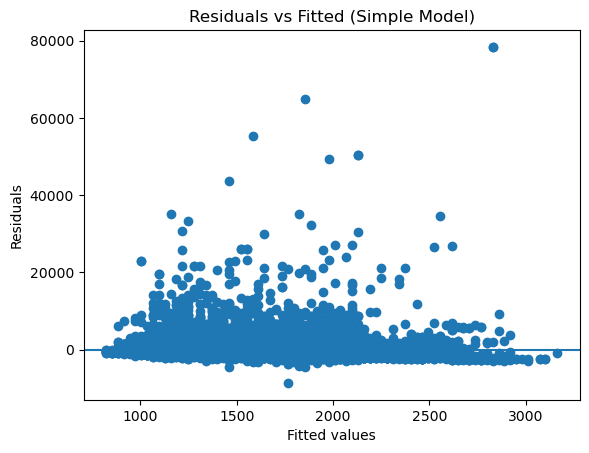

In [12]:
# residuals vs fitted
fitted = model_simple.fittedvalues
residuals = model_simple.resid

plt.figure()
plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Simple Model)")
plt.show()

## Residual diagnostics for the simple model

Regression assumptions are evaluated using diagnostic plots:

- **Residuals vs Fitted**:
  - checks linearity
  - checks constant variance (homoskedasticity)

- **Normal Q–Q plot**:
  - checks if residuals are approximately normal

If assumptions appear violated, it does not necessarily invalidate coefficient estimates,
but it affects inference (standard errors, p-values) and motivates robust methods.

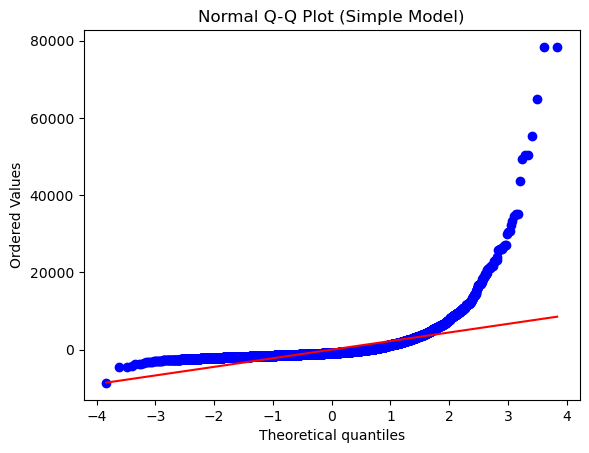

In [13]:
# Q-Q plot
plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot (Simple Model)")
plt.show()

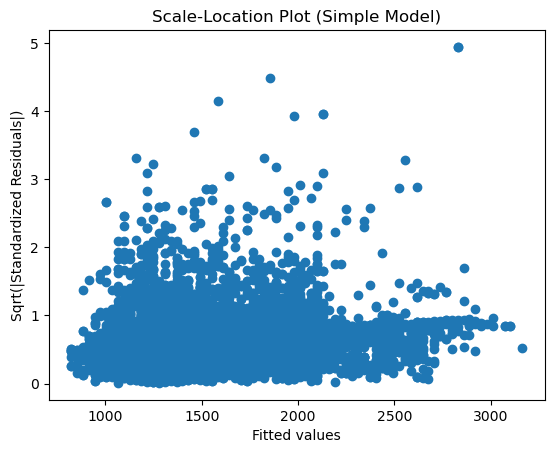

In [14]:
# Scale-Location plot
std_resid = model_simple.get_influence().resid_studentized_internal
plt.figure()
plt.scatter(fitted, np.sqrt(np.abs(std_resid)))
plt.xlabel("Fitted values")
plt.ylabel("Sqrt(|Standardized Residuals|)")
plt.title("Scale-Location Plot (Simple Model)")
plt.show()

In [16]:
# heteroskedasticity test
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, X_simple)
labels = ["LM Stat", "LM p-value", "F Stat", "F p-value"]

print(dict(zip(labels, bp_test)))

{'LM Stat': np.float64(44.80791886623805), 'LM p-value': np.float64(2.173419319581832e-11), 'F Stat': np.float64(44.980456476579405), 'F p-value': np.float64(2.086280695404689e-11)}


## test for heteroskedasticity

In addition to visual inspection, I apply a formal test:

- **Breusch–Pagan test**
  - Null hypothesis: constant variance (homoskedasticity)
  - Small p-value suggests heteroskedasticity

This supports the decision to use robust standard errors.

In [17]:
# robust standard errors (HC3)
model_simple_robust = model_simple.get_robustcov_results(cov_type="HC3")
model_simple_robust.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                balance   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     56.27
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           6.80e-14
Time:                        20:02:00   Log-Likelihood:            -1.0594e+05
No. Observations:               11162   AIC:                         2.119e+05
Df Residuals:                   11160   BIC:                         2.119e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        274.9242    155.912      1.763      0.078     -30.691     580.539
age           30.4040      4.053      7.501      0.000      22.459      38.349
==============================================================================
Omnibus:                    15714.156   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          7296466.486
Skew:                           8.137   Prob(JB):                         0.00
Kurtosis:                     127.192   Cond. No.                         155.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

## bust standard errors (HC3) for valid inference

If heteroskedasticity is present, coefficient estimates can remain unbiased,
but **standard errors may be incorrect**.

To address this, I compute **HC3 robust standard errors**.
This keeps the same coefficients but adjusts standard errors and p-values for more reliable inference.

In [20]:
# building multiple regression design matrix
# Convert boolean columns to 0/1
bool_cols = X_multi.select_dtypes(include="bool").columns
X_multi[bool_cols] = X_multi[bool_cols].astype(int)

# check dtypes
print(X_multi.dtypes.value_counts())

# Fitting the model 
model_multi = sm.OLS(y, X_multi).fit()
model_multi.summary()

int64      23
float64     1
Name: count, dtype: int64


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                balance   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     15.63
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           4.32e-61
Time:                        20:08:23   Log-Likelihood:            -1.0584e+05
No. Observations:               11162   AIC:                         2.117e+05
Df Residuals:                   11138   BIC:                         2.119e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -303.7984    240.868     -1.261      0.207    -775.941     168.345
age                    32.6518      3.607      9.053      0.000      25.582      39.722
duration                0.2359      0.087      2.710      0.007       0.065       0.407
campaign               -8.9431     11.160     -0.801      0.423     -30.819      12.933
previous               28.3807     15.269      1.859      0.063      -1.548      58.310
pdays                   0.1706      0.324      0.526      0.599      -0.465       0.806
job_blue-collar        71.1573    118.545      0.600      0.548    -161.211     303.526
job_entrepreneur      250.6939    198.901      1.260      0.208    -139.187     640.575
job_housemaid        -186.0609    218.449     -0.852      0.394    -614.260     242.138
job_management        204.7172    125.239      1.635      0.102     -40.774     450.208
job_retired           228.1748    169.101      1.349      0.177    -103.293     559.643
job_self-employed     414.3600    184.909      2.241      0.025      51.906     776.814
job_services          -35.7464    136.583     -0.262      0.794    -303.473     231.980
job_student           347.7644    200.105      1.738      0.082     -44.476     740.005
job_technician        260.4816    115.582      2.254      0.024      33.921     487.042
job_unemployed       -128.0626    191.106     -0.670      0.503    -502.665     246.540
job_unknown           211.5871    399.836      0.529      0.597    -572.163     995.337
marital_married       318.7934     97.777      3.260      0.001     127.133     510.454
marital_single        425.5216    113.148      3.761      0.000     203.731     647.312
education_secondary     9.5487    101.916      0.094      0.925    -190.225     209.322
education_tertiary    392.5711    122.059      3.216      0.001     153.315     631.827
education_unknown     114.8570    172.159      0.667      0.505    -222.604     452.318
housing_yes          -257.0282     64.504     -3.985      0.000    -383.467    -130.589
loan_yes             -660.1434     90.571     -7.289      0.000    -837.678    -482.609
==============================================================================
Omnibus:                    15773.362   Durbin-Watson:                   1.976
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          7563065.882
Skew:                           8.185   Prob(JB):                         0.00
Kurtosis:                     129.466   Cond. No.                     7.10e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.1e+03. This might indicate that there are
strong multicollinearity or other numerical problems.


## Multiple Linear Regression (adding more predictors)

The simple model (balance ~ age) explains only a small portion of variability.
To improve explanatory power, I fit a multiple regression model using additional predictors.

This matches the exam concept of moving from simple to multiple regression:


$$
\text{balance}_i
=
\beta_0
+ \beta_1\,\text{age}_i
+ \beta_2\,\text{duration}_i
+ \beta_3\,\text{campaign}_i
+ \beta_4\,\text{previous}_i
+ \beta_5\,\text{pdays}_i
+ \sum_{k=1}^{K-1}\gamma_k\,D_{ik}
+ \epsilon_i
$$

where:

- $\text{balance}_i$ is the yearly average account balance for customer $i$ (response variable).
- $\beta_0$ is the intercept.
- $\text{age}_i, \text{duration}_i, \text{campaign}_i, \text{previous}_i, \text{pdays}_i$ are numeric predictors for customer $i$.
- $D_{ik}$ are **dummy variables** (0/1 indicators) created from categorical predictors (e.g., job, marital, education, housing, loan).  
  Using $K-1$ dummies avoids perfect multicollinearity (the omitted category is the reference group).
- $\epsilon_i$ is the error term, capturing unobserved factors that affect balance.

For categorical predictors (e.g., job, education), I use **dummy variables** (0/1 indicators),
which is the standard approach for including categories in linear regression.

Each coefficient represents the expected change in $\text{balance}$ for a one-unit increase in that predictor, **holding all other variables constant**.
For dummy variables, $\gamma_k$ represents the expected difference in balance between category $k$ and the reference category, holding other variables constant.

## Fit the multiple regression model

Here I:
1. select a set of predictors (numeric + categorical),
2. convert categorical variables into dummy variables (drop_first=True to avoid redundancy),
3. add an intercept,
4. fit the OLS multiple regression model.

The coefficient interpretations in multiple regression are **partial effects**:
each coefficient is interpreted **holding other variables constant**.

In [32]:
import numpy as np

def model_stats(m):
    r2 = m.rsquared
    adj_r2 = m.rsquared_adj
    rse = np.sqrt(m.mse_resid)
    return r2, adj_r2, rse

r2_s, adjr2_s, rse_s = model_stats(model_simple)
r2_m, adjr2_m, rse_m = model_stats(model_multi)

print("SIMPLE  : R2 =", r2_s, " R2 =", adjr2_s, "RSE =", rse_s)
print("MULTIPLE: R2 =", r2_m, " R2 =", adjr2_m, "RSE =", rse_m)

SIMPLE  : R2 = 0.01261126497928755  R2 = 0.012522789286185332 RSE = 3205.1541149486784
MULTIPLE: R2 = 0.03127505735466074  R2 = 0.02927463773885508 RSE = 3177.8512464034166


## Compare model fit (Simple vs Multiple)

To compare the models fairly, I report:
- \(R^2\) (explained variance),
- **Adjusted \(R^2\)** (accounts for number of predictors),
- RSE (typical prediction error).

An increase in adjusted \(R^2\) suggests that added predictors provide real improvement
rather than just overfitting.

In [26]:
model_multi_robust = model_multi.get_robustcov_results(cov_type="HC3")
model_multi_robust.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                balance   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     15.90
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           2.65e-62
Time:                        20:17:43   Log-Likelihood:            -1.0584e+05
No. Observations:               11162   AIC:                         2.117e+05
Df Residuals:                   11138   BIC:                         2.119e+05
Df Model:                          23                                         
Covariance Type:                  HC3                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -303.7984    280.819     -1.082      0.279    -854.254     246.657
age                    32.6518      4.532      7.204      0.000      23.768      41.536
duration                0.2359      0.085      2.775      0.006       0.069       0.403
campaign               -8.9431     11.977     -0.747      0.455     -32.420      14.534
previous               28.3807     13.259      2.141      0.032       2.391      54.370
pdays                   0.1706      0.317      0.538      0.591      -0.451       0.792
job_blue-collar        71.1573     92.243      0.771      0.440    -109.656     251.970
job_entrepreneur      250.6939    241.862      1.037      0.300    -223.398     724.785
job_housemaid        -186.0609    177.936     -1.046      0.296    -534.847     162.725
job_management        204.7172    109.651      1.867      0.062     -10.218     419.652
job_retired           228.1748    200.189      1.140      0.254    -164.231     620.581
job_self-employed     414.3600    226.437      1.830      0.067     -29.497     858.217
job_services          -35.7464     95.916     -0.373      0.709    -223.758     152.265
job_student           347.7644    174.850      1.989      0.047       5.027     690.502
job_technician        260.4816     99.372      2.621      0.009      65.696     455.268
job_unemployed       -128.0626    129.500     -0.989      0.323    -381.906     125.781
job_unknown           211.5871    401.344      0.527      0.598    -575.119     998.293
marital_married       318.7934     98.385      3.240      0.001     125.941     511.646
marital_single        425.5216    110.319      3.857      0.000     209.277     641.767
education_secondary     9.5487    106.264      0.090      0.928    -198.748     217.845
education_tertiary    392.5711    123.209      3.186      0.001     151.060     634.082
education_unknown     114.8570    171.664      0.669      0.503    -221.636     451.350
housing_yes          -257.0282     61.058     -4.210      0.000    -376.712    -137.344
loan_yes             -660.1434     67.587     -9.767      0.000    -792.627    -527.660
==============================================================================
Omnibus:                    15773.362   Durbin-Watson:                   1.976
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          7563065.882
Skew:                           8.185   Prob(JB):                         0.00
Kurtosis:                     129.466   Cond. No.                     7.10e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 7.1e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Robust standard errors for multiple regression (HC3)

Because heteroskedasticity is common in real-world observational data,
I compute **HC3 robust standard errors** for the multiple regression.

This helps ensure hypothesis tests and confidence intervals are more reliable
even if the constant variance assumption is violated.

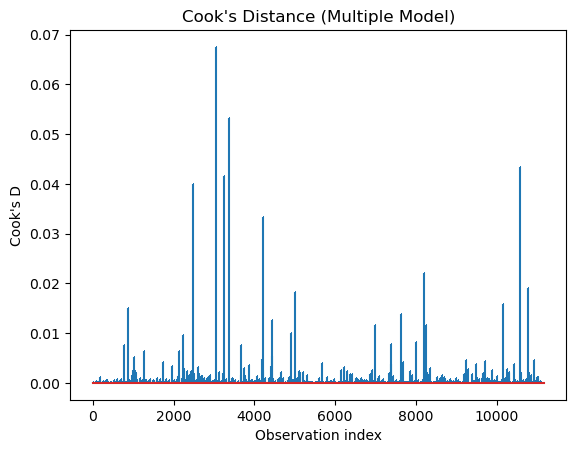

Max Cook's D: 0.06754180233643367


In [22]:
# Cook's distance for multiple regression
influence_multi = model_multi.get_influence()
cooks_d = influence_multi.cooks_distance[0]

plt.figure()
plt.stem(cooks_d, markerfmt=",")
plt.title("Cook's Distance (Multiple Model)")
plt.xlabel("Observation index")
plt.ylabel("Cook's D")
plt.show()

print("Max Cook's D:", cooks_d.max())

## Influence diagnostics using Cook’s Distance

Cook’s Distance measures how much the fitted regression would change
if a particular observation were removed.

Rule of thumb:
- values close to 1 may indicate influential observations.

If Cook’s Distance values are small across the dataset,
it suggests the model is not being driven by a small number of extreme points.

## Multicollinearity 

With many predictors (especially dummy variables), multicollinearity can occur.
This may inflate standard errors and make individual coefficients less stable.

A large condition number (or high VIF values, if computed) suggests multicollinearity.
This does not necessarily invalidate the model, but it affects interpretation and inference.

## Association vs Causation 

Regression analysis estimates **associations**, not causal effects.

Even if a predictor is statistically significant, it does not imply changing that variable
would cause balance to change.

Unobserved confounders (e.g., income, wealth, savings habits) may explain the relationship.
A causal claim would require a causal identification strategy (experiment, IV, natural experiment, etc.).

## conclusion

- The multiple regression model improves fit modestly relative to the simple model,
  as shown by increased \(R^2\) / adjusted \(R^2\) and reduced RSE.
- However, overall explanatory power remains limited, suggesting important predictors
  of balance are not included in the dataset.
- Robust (HC3) standard errors and influence diagnostics (Cook’s Distance) strengthen the reliability
  of inference and confirm the model is not driven by single observations.
- Results should be interpreted as **associations**, not causal effects.